In [ ]:
!pip install numpy scipy scikit-learn pot

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 27.5 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/judelo/gmmot.git

Cloning into 'gmmot'...
remote: Enumerating objects: 74, done.
remote: Total 74 (delta 0), reused 0 (delta 0), pack-reused 74 (from 1)
Receiving objects: 100% (74/74), 20.31 MiB | 21.23 MiB/s, done.
Resolving deltas: 100% (29/29), done.


In [ ]:
import sys
import os

# gmmot.py が入っている python フォルダを直接パスに追加
python_folder = '/content/gmmot/python'

if python_folder not in sys.path:
    sys.path.append(python_folder)

# これで直接 gmmot をインポート可能
import gmmot

# 動作確認
print(gmmot)


<module 'gmmot' from '/content/gmmot/python/gmmot.py'>


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as spl
import scipy.spatial as sps
import ot
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.graph_objects as go
import sklearn.mixture as sklmi
import sklearn.manifold as sklma
from tqdm import tqdm
import warnings
import os, sys
import itertools
import scipy as sp
from sklearn.datasets import make_blobs
from scipy.stats import special_ortho_group
from sklearn.neighbors import NearestNeighbors



### utils ###

class Gaussian:
    ### class encoding a Gaussian distribution ###

    def __init__(self,mean,cov):
        self.mean = np.array(mean)
        self.cov = np.array(cov)
        self.dim = len(mean)

    def sample(self,n_samples):
        return np.random.multivariate_normal(self.mean,self.cov,n_samples)

    def pdf(self,x):
        return multivariate_normal.pdf(x,mean=self.mean,cov=self.cov)



class GaussianMixture:
    ### Encode a Gaussian distribution ###

    def __init__(self,weights_list,mean_list,cov_list):
        self.comp = [Gaussian(mean_list[k],cov_list[k]) for k in range(len(mean_list))]
        self.comp_mean = np.array(mean_list)
        self.comp_cov = np.array(cov_list)
        self.weights = np.array(weights_list)
        self.dim = len(mean_list[0])
        self.K = len(mean_list)


    def sample(self,n_samples,return_K=False):
        """
        if return_K, return the list of component indice for each sample
        """
        idx_list = np.random.choice(np.arange(self.K),n_samples,p=self.weights)
        samples_list = [np.random.multivariate_normal(self.comp_mean[i],self.comp_cov[i]) for i in idx_list]
        if return_K:
            return np.array(samples_list), idx_list
        else:
            return np.array(samples_list)

    def mean(self):
        ### return the mean of the Gaussian mixture
        return np.average(self.comp_mean,axis=0,weights=self.weights)

    def cov(self):
        ### return the covariance matrix of the Gaussian mixture
        A = sum([self.weights[k]*(self.comp_cov[k]+np.outer(self.comp_mean[k],self.comp_mean[k])) for k in range(self.K)])
        mean = self.mean()
        return A - np.outer(mean,mean)


    def pdf(self,x):
        return sum([self.weights[k]*multivariate_normal.pdf(x,mean=self.comp_mean[k],cov=self.comp_cov[k]) for k in range(self.K)])


    def plot_scatter_2d(self,n_samples,T=None,*args):
        ### utils for Figures 3 and 4
        X, idx_list = self.sample(n_samples,True)
        grad_color = np.array([(x/np.max(X[:,0]),y/np.max(X[:,1]),x/np.max(X[:,0]),1) for x,y in X])
        if T is not None:
            Y = np.array([T(X[k],idx_list[k],*args) for k in range(len(X))])
        else:
            Y = X
        cmap_list = ['spring', 'summer', 'autumn', 'winter', 'cool',
                      'Wistia', 'hot', 'afmhot', 'gist_heat', 'copper','viridis', 'plasma', 'inferno', 'magma', 'cividis']
        for k in range(self.K):
            Z = Y[idx_list==k]
            plt.scatter(Z[:,0],Z[:,1],color=X[idx_list==k][:,0],s=10)
        plt.axis('equal')



    def pdist(self,f):
        ### compute pairwise distances matrix
        dist_list = [[f(self.comp_mean[k],self.comp_mean[l],self.comp_cov[k],self.comp_cov[l]) for l in range(k+1,self.K)] for k in range(self.K)][:-1]
        dist_matrix = np.zeros((self.K,self.K))
        for k in range(self.K):
            for l in range(k+1,self.K):
                dist_matrix[k,l] = dist_list[k][l-k-1]
                dist_matrix[l,k] = dist_matrix[k,l]
        return dist_matrix






def gmm_transform(mu,P=None,b=None):
    ### Apply a linear transformation x -> Px + b to the Gaussian mixture
    if P is None:
        P = np.eye(mu.dim)
    if b is None:
        b = np.zeros(P.shape[0])
    mean_list = [P.dot(m) + b for m in mu.comp_mean]
    cov_list = [P@A@P.T for A in mu.comp_cov]
    return GaussianMixture(mu.weights,mean_list,cov_list)


def I(m,n):
    ### rectangular matrix (I_n  0)^T
    I = np.zeros((m,n))
    I[:n,:n] = np.eye(n)
    return I


def proj_stiefel(A):
    ### projection on Stiefel Manifold
    m,n = A.shape
    U, s, VT = spl.svd(A)
    return U @ I(m,n) @ VT


def GaussianW2(mean_0,mean_1,Cov_0,Cov_1):
    ### W_2 between Gaussian distributions
    sqCov_1 = spl.sqrtm(Cov_1).real
    return spl.norm(mean_0 - mean_1)**2 + np.trace(Cov_0) + np.trace(Cov_1) - 2*np.trace(spl.sqrtm(sqCov_1@Cov_0@sqCov_1).real)

def gaussian_cost_matrix(gmm):
    K = gmm.K
    C = np.zeros((K,K))
    for i in range(K):
        for j in range(K):
            C[i,j] = GaussianW2(gmm.comp_mean[i], gmm.comp_mean[j],
                                gmm.comp_cov[i],  gmm.comp_cov[j])
    return C

def gaussian_W(gmm1, gmm2):
    K = gmm1.K
    L = gmm2.K
    C = np.zeros((K,L))
    for i in range(K):
        for j in range(L):
            C[i,j] = GaussianW2(gmm1.comp_mean[i], gmm2.comp_mean[j],
                                gmm1.comp_cov[i], gmm2.comp_cov[j])
    return C




def grad_gauss(P,Cov_0,Cov_1):
    ### grad of P -> tr(Cov_1^{\frac{1}{2}}P^TCov_0PCov_1^{\frac{1}{2})
    sqCov_1 = spl.sqrtm(Cov_1).real
    A = Cov_0@P@sqCov_1
    B = spl.inv(spl.sqrtm(sqCov_1@P.T@A)).real
    return A @ B @ sqCov_1



def grad(P,weights,mu,nu):
    ### grad of P -> \sum_{k,l} weights[k,l]W_2^2(\mu_k,P_{\#}\nu_l)
    return 2*sum([weights[k,l]*(-np.outer(mu.comp_mean[k],nu.comp_mean[l])
                + P@np.outer(nu.comp_mean[l],nu.comp_mean[l])
                - grad_gauss(P,mu.comp_cov[k],nu.comp_cov[l])) for k in range(mu.K) for l in range(nu.K)])




def proj_gradient_descent(P,weights,mu,nu,alpha,n_iter=150):
    ### projected gradient descent on the Stiefel manifold
    loss = [sum([weights[k,l]*GaussianW2(0,0,mu.comp_cov[k],P@nu.comp_cov[l]@P.T) for k in range(mu.K) for l in range(nu.K)])]
    for k in range(n_iter):
        P = proj_stiefel(P-alpha*grad(P,weights,mu,nu))
        loss.append(sum([weights[k,l]*GaussianW2(0,0,mu.comp_cov[k],P@nu.comp_cov[l]@P.T) for k in range(mu.K) for l in range(nu.K)]))
    return P, loss



def T_map_Gaussian(x,mu,nu):
    ### Transport map between two Gaussian distributions mu and nu
    invcov0 = spl.inv(spl.sqrtm(mu.cov).real)
    sqcov0 = spl.sqrtm(mu.cov).real
    A = invcov0@spl.sqrtm(sqcov0@nu.cov@sqcov0)@invcov0
    if len(x.shape)==1:
        return nu.mean + A@(x - mu.mean)
    else:
        return nu.mean + np.einsum('ij,bj -> bi',A,x - mu.mean)


def T_map_Gaussian_rand(x,mu,nu,idx_list):
    ### Transport map between two Gaussian distributions mu and nu (utils for T_rand)
    invcov0 = [spl.inv(spl.sqrtm(mu.comp[k].cov).real) for k in range(mu.K)]
    sqcov0 = [spl.sqrtm(mu.comp[k].cov).real for k in range(mu.K)]
    A_list = [[invcov0[k]@spl.sqrtm(sqcov0[k]@nu.comp[l].cov@sqcov0[k])@invcov0[k] for l in range(nu.K)] for k in range(mu.K)]
    return np.array([nu.comp[idx[1]].mean + A_list[idx[0]][idx[1]]@(x[i] - mu.comp[idx[0]].mean) for i, idx in enumerate(idx_list)])



def T_mean(X,mu,nu,P,weights):
    mu_P_centered = gmm_transform(mu,P=P.T,b=-P.T@mu.mean())
    nu_centered = gmm_transform(nu,b=-nu.mean())
    pdf_comp = [mu.comp[k].pdf(X) for k in range(mu.K)]
    ipdf_mu = 1./mu.pdf(X)
    if len(X.shape)==1:
        X_P = P.T@(X - mu.mean())
        Y = sum([weights[k,l]*pdf_comp[k]*T_map_Gaussian(X_P,mu_P_centered.comp[k],nu_centered.comp[l]) for k in range(mu.K) for l in range(nu.K)])*ipdf_mu
    else:
        X_P = np.einsum('ij,bj->bi',P.T,X - mu.mean())
        Y = np.einsum('bi,b -> bi',sum([weights[k,l]*np.einsum('bi,b -> bi',T_map_Gaussian(X_P,mu_P_centered.comp[k],nu_centered.comp[l]),pdf_comp[k]) for k in range(mu.K) for l in range(nu.K)]),ipdf_mu)
    return Y + nu.mean()


def T_rand(x,mu,nu,P,weights):
    mu_P_centered = gmm_transform(mu,P=P.T,b=-P.T@mu.mean())
    nu_centered = gmm_transform(nu,b=-nu.mean())
    rng = np.random.default_rng()
    probs = np.array([weights[k,l]*mu.comp[k].pdf(x)/mu.pdf(x) for k in range(mu.K) for l in range(nu.K)])
    idx_list = [rng.choice([[k,l] for k in range(mu.K) for l in range(nu.K)],p=prob) for prob in probs.T]
    return T_map_Gaussian_rand(x,mu_P_centered,nu_centered,idx_list)




## Main algo



def MGW2_GM(mu,nu):
    ### core method between two Gaussian mixtures (returns a distance)
    return ot.gromov.gromov_wasserstein2(mu.pdist(GaussianW2),nu.pdist(GaussianW2),mu.weights,nu.weights,loss_fun='square_loss')



def aMGW2_GM(mu,nu,n_step=10,reg_init=1,beta=0.95,verbose=False):
    ### core method with annealed scheme
    reg = reg_init
    weights = np.outer(mu.weights,nu.weights)
    for k in range(n_step):
        weights = ot.gromov.entropic_gromov_wasserstein(mu.pdist(GaussianW2),nu.pdist(GaussianW2),mu.weights,nu.weights,loss_fun='square_loss',epsilon=reg,G0=weights)
        reg *= beta
    return ot.gromov.gromov_wasserstein2(mu.pdist(GaussianW2),nu.pdist(GaussianW2),mu.weights,nu.weights,loss_fun='square_loss',G0=weights)




def MGW2(X,Y,n_components=20,annealing=False):
    ### MGW2 between two clouds of points (returns a distance)
    mix = sklmi.GaussianMixture(n_components=n_components)
    mix.fit(X)
    mu = GaussianMixture(mix.weights_,mix.means_,mix.covariances_)
    del mix
    mix = sklmi.GaussianMixture(n_components=n_components)
    mix.fit(Y)
    nu = GaussianMixture(mix.weights_,mix.means_,mix.covariances_)
    del mix
    if annealing:
        return aMGW2_GM(mu,nu)
    else:
        return MGW2_GM(mu,nu)



def MGW2_GM_coup(mu,nu):
    ### core method between two Gaussian Mixtures (return a coupling between Gaussian components)
    return ot.gromov.gromov_wasserstein(mu.pdist(GaussianW2),nu.pdist(GaussianW2),mu.weights,nu.weights,loss_fun='square_loss')



def aMGW2_GM_coup(mu,nu,n_step=10,reg_init=1,beta=0.95,verbose=False):
    ### core method with annealed scheme
    reg = reg_init
    weights = np.outer(mu.weights,nu.weights)
    for k in range(n_step):
        weights = ot.gromov.entropic_gromov_wasserstein(mu.pdist(GaussianW2),nu.pdist(GaussianW2),mu.weights,nu.weights,loss_fun='square_loss',epsilon=reg,G0=weights)
        reg *= beta
    return ot.gromov.gromov_wasserstein(mu.pdist(GaussianW2),nu.pdist(GaussianW2),mu.weights,nu.weights,loss_fun='square_loss',G0=weights)



def MGW2_coup(X,Y,n_components=20,annealing=False,method='T_rand',points=True,return_both=False,verbose=False):
    """
    MGW2 between two clouds of points (return a map between the points)
    If points = False, return the direct output of the T_mean or T_rand map (not in Y),
    if points = True, return the idxs of the points in Y where the points in X are transported at.
    """
    if verbose:
        print('fitting mixture 1')
    mix = sklmi.GaussianMixture(n_components=n_components)
    mix.fit(X)
    mu = GaussianMixture(mix.weights_,mix.means_,mix.covariances_)
    del mix
    if verbose:
        print('fitting mixture 2')
    mix = sklmi.GaussianMixture(n_components=n_components)
    mix.fit(Y)
    nu = GaussianMixture(mix.weights_,mix.means_,mix.covariances_)
    del mix
    if verbose:
        print('deriving coupling between GMMs')
    if annealing:
        weights = aMGW2_GM_coup(mu,nu)
    else:
        weights = MGW2_GM_coup(mu,nu)
    if verbose:
        print('deriving map from coupling')
    P = proj_stiefel(sum([weights[k,l]*np.outer(mu.comp_mean[k],nu.comp_mean[l]) for k in range(mu.K) for l in range(nu.K)]))
    P, loss  = proj_gradient_descent(P,weights,mu,nu,1)
    if method=='T_mean':
        Z = T_mean(X,mu,nu,P,weights)
    elif method=='T_rand':
        Z = T_rand(X,mu,nu,P,weights)
    if return_both:
        idx = nbrs.kneighbors(Z,return_distance=False).ravel()
        return idx, Z
    elif points:
        nbrs = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(Y)
        idx = nbrs.kneighbors(Z,return_distance=False).ravel()
        return idx
    else:
        return Z


### MEW2 ###


def MEW2_GM(mu,nu,alpha,n_iter_P=150,eps=1e-3,n_iter_max=1000,init='Gaussian',initw=None,init_phase=True,symmetry=True,verbose=False):

    ### core method between two Gaussian mixtures mu and nu

    def twistedGaussianW2(mean_0,mean_1,Cov_0,Cov_0_full,Cov_1):
        sqCov_1 = spl.sqrtm(Cov_1).real
        return spl.norm(mean_0 - mean_1)**2 + np.trace(Cov_0_full) + np.trace(Cov_1) - 2*np.trace(spl.sqrtm(sqCov_1@Cov_0@sqCov_1).real)


    def compute_weights_loss(P,mu,nu,loss_only=False,w=None):
        mu_P = gmm_transform(mu,P=P.T)
        M = np.array([[twistedGaussianW2(mu_P.comp_mean[k],nu.comp_mean[l],mu_P.comp_cov[k],mu.comp_cov[k],nu.comp_cov[l]) for l in range(nu.K)] for k in range(mu.K)])
        del mu_P
        if not loss_only:
            weights = ot.emd(mu.weights,nu.weights,M)
        else:
            weights = w
        loss = np.sum(weights*M)
        if loss_only:
            return loss
        else:
            return weights, loss


    def initialize(P,mu,nu,symmetry=False):
        P_list = P@[np.diag(a) for a in itertools.product([1,-1],repeat=P.shape[1])]
        weights_list, loss_list = [], []
        for k in range(len(P_list)):
            weights, loss = compute_weights_loss(P_list[k],mu,nu)
            weights_list.append(weights)
            loss_list.append(loss)
        idx = np.argmin(loss_list)
        P = P_list[idx]
        weights = weights_list[idx]
        loss = loss_list[idx]
        if symmetry:
            P_list = [P[:,a] for a in itertools.permutations(range(P.shape[1]))]
            weights_list, loss_list = [], []
            for k in range(len(P_list)):
                weights, loss = compute_weights_loss(P_list[k],mu,nu)
                weights_list.append(weights)
                loss_list.append(loss)
            idx = np.argmin(loss_list)
            P = P_list[idx]
            weights = weights_list[idx]
            loss = loss_list[idx]

        return P, weights, loss


    if type(init) == str:
        s0, P0 = spl.eigh(mu.cov())
        s1, P1 = spl.eigh(nu.cov())
        P0 = P0[:,::-1]
        P1 = P1[:,::-1]


    mu = gmm_transform(mu,b=-mu.mean())
    nu = gmm_transform(nu,b=-nu.mean())





    if type(init) == str:
        if init=='Gaussian':
            P = P0@I(mu.dim,nu.dim)@P1.T
        elif init=='random':
            P = proj_stiefel(np.random.rand(mu.dim,nu.dim))
    else:
        P = init
    if initw is None:
        if init_phase:
            P, weights, loss = initialize(P,mu,nu,symmetry)
        else:
            weights, loss = compute_weights_loss(P,mu,nu)
    else:
        weights = initw
        loss = compute_weights_loss(P,mu,nu,True,weights)
    loss_old = 0
    #print('initialization, loss = ' + str(loss))
    n_iter = 0
    while n_iter < n_iter_max and np.abs(loss - loss_old) > eps:
        if verbose:
            print('iteration ' + str(n_iter) + ': loss = ' + str(loss))
        loss_old = loss
        P, _ = proj_gradient_descent(P,weights,mu,nu,alpha,n_iter = n_iter_P)
        weights, loss = compute_weights_loss(P,mu,nu)
        #print('iteration: ' + str(k+1) + ', loss = ' + str(loss))
        n_iter += 1

    return  P, weights, loss



def EW2(X,Y,a=None,b=None,eps=1e-3,n_iter_max=10000,verbose=False):
    ### EW2 between two clouds of points (https://arxiv.org/pdf/1806.09277.pdf)
    m = X.shape[1]
    n = Y.shape[1]
    if a is None:
        a = ot.unif(X.shape[0])
    if b is None:
        b = ot.unif(Y.shape[0])
    P = proj_stiefel(np.random.rand(m,n))
    M = ot.dist(X,np.einsum('mn,bn->bm',P,Y))
    weights = ot.emd(a,b,M,numItermax=1000000)
    loss = np.trace(weights.T@M)
    loss_old = 0
    n_iter = 0
    while n_iter < n_iter_max and np.abs(loss-loss_old) > eps:
        if verbose:
            print('iteration ' + str(n_iter) + ': loss = ' + str(loss))
        loss_old = loss
        P = proj_stiefel(X.T@weights@Y)
        M = ot.dist(X,np.einsum('mn,bn->bm',P,Y))
        weights = ot.emd(a,b,M,numItermax=1000000)
        loss = np.trace(weights.T@M)
        n_iter += 1
    return P, weights, loss


def aEW2(X,Y,a=None,b=None,eps=1e-3,n_iter_max=10000,reg_init=1,beta=0.95,verbose=False):
    ### EW2 with annealed scheme (https://arxiv.org/pdf/1806.09277.pdf)
    m = X.shape[1]
    n = Y.shape[1]
    P = proj_stiefel(np.random.rand(m,n))
    M = ot.dist(X,np.einsum('mn,bn->bm',P,Y))
    if a is None:
        a = ot.unif(X.shape[0])
    if b is None:
        b = ot.unif(Y.shape[0])
    reg = reg_init
    weights = ot.bregman.sinkhorn_stabilized(a,b,M,reg)
    loss = np.trace(weights.T@M)
    loss_old = 0
    n_iter = 0
    while n_iter < n_iter_max and np.abs(loss-loss_old) > eps:
        if verbose:
            print('iteration ' + str(n_iter) + ': loss = ' + str(loss))
        loss_old = loss
        reg *= beta
        P = proj_stiefel(X.T@weights@Y)
        M = ot.dist(X,np.einsum('mn,bn->bm',P,Y))
        a = ot.unif(X.shape[0])
        b = ot.unif(Y.shape[0])
        weights = ot.bregman.sinkhorn_stabilized(a,b,M,reg)
        loss = np.trace(weights.T@M)
        n_iter += 1
    return P, weights, loss


def MEW2(X,Y,n_components=20,annealing=True,n_iter_annealing=10,beta=0.99):
    ### MEW2 between two clouds of points (returns a distance)
    mix = sklmi.GaussianMixture(n_components=n_components)
    mix.fit(X)
    mu = GaussianMixture(mix.weights_,mix.means_,mix.covariances_)
    del mix
    mix = sklmi.GaussianMixture(n_components=n_components)
    mix.fit(Y)
    nu = GaussianMixture(mix.weights_,mix.means_,mix.covariances_)
    del mix
    if annealing:
        P, weights, loss =  aEW2(mu.comp_mean,nu.comp_mean,n_iter_max=n_iter_annealing,beta=0.99,verbose=False)
        P, weights, loss = MEW2_GM(mu,nu,alpha=0.01,eps=1e-3,n_iter_P=150,init=P,init_phase=False,symmetry=False,verbose=False)
    else:
        P, weights, loss = MEW2_GM(mu,nu,alpha=0.01,eps=1e-3,n_iter_P=150,init_phase=True,symmetry=True,verbose=False)
    return loss


def MEW2_coup(X,Y,n_components=20,annealing=True,n_iter_annealing=10,beta=0.99,method='T_rand',points=True,return_both=False):
    """
    MEW2 between two clouds of points (return a map between the points)
    If points = False, return the direct output of the T_mean or T_rand map (not in Y),
    if points = True, return the idxs of the points in Y where the points in X are transported at.
    """
    mix = sklmi.GaussianMixture(n_components=n_components)
    mix.fit(X)
    mu = GaussianMixture(mix.weights_,mix.means_,mix.covariances_)
    del mix
    mix = sklmi.GaussianMixture(n_components=n_components)
    mix.fit(Y)
    nu = GaussianMixture(mix.weights_,mix.means_,mix.covariances_)
    del mix
    if annealing:
        P, weights, loss =  aEW2(mu.comp_mean,nu.comp_mean,n_iter_max=n_iter_annealing,beta=0.99,verbose=False)
        P, weights, loss = MEW2_GM(mu,nu,alpha=0.01,eps=1e-3,n_iter_P=150,init=P,init_phase=False,symmetry=False,verbose=False)
    else:
        P, weights, loss = MEW2_GM(mu,nu,alpha=0.01,eps=1e-3,n_iter_P=150,init_phase=True,symmetry=True,verbose=False)
    if method=='T_mean':
        Z = T_mean(X,mu,nu,P,weights)
    elif method=='T_rand':
        Z = T_rand(X,mu,nu,P,weights)
    if return_both:
        nbrs = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(Y)
        idx = nbrs.kneighbors(Z,return_distance=False).ravel()
        return idx, Z
    elif points:
        nbrs = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(Y)
        idx = nbrs.kneighbors(Z,return_distance=False).ravel()
        return idx
    else:
        return Z



In [ ]:
import numpy as np
import ot
from ot.backend import get_backend

def to_numpy(x):
    """Convert list/array/tensor to numpy."""
    try:
        return np.asarray(x)
    except:
        return x

import numpy as np

def partial_wasserstein_lagrange_entropic(
    a, b, M, Lambda=None, epsilon=1e-2, nb_dummies=1, log=False, **kwargs
):
    """
    Entropic Lagrangian Partial Optimal Transport (Cuturi et al., 2016)
    Implemented with inequality-constrained Sinkhorn.
    Arguments:
        a, b : probability weights (sum <= 1)
        M    : cost matrix
        Lambda: Lagrange multiplier (lambda)
        epsilon : entropic regularization
    """

    # --- convert to numpy ---
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    M = np.asarray(M, float)

    # --- default λ ---
    if Lambda is None:
        Lambda = float(np.max(M)) + 1.0

    # --- modified cost ---
    C = M - Lambda

    # --- Gibbs kernel ---
    K = np.exp(-C / epsilon)     # entropic kernel

    # --- initialize dual variables ---
    u = np.ones_like(a)
    v = np.ones_like(b)

    # --- inequality-constrained Sinkhorn iterations ---
    for _ in range(2000):
        u_prev = u.copy()

        # inequality constraint: row sums <= a
        Ku = K @ v
        u = np.minimum(a / (Ku + 1e-300), 1.0)

        # inequality constraint: col sums <= b
        Kv = K.T @ u
        v = np.minimum(b / (Kv + 1e-300), 1.0)

        # convergence check
        if np.linalg.norm(u - u_prev) < 1e-14:
            break

    # --- transport plan ---
    gamma = np.diag(u) @ K @ np.diag(v)
    print(gamma)
    print(np.sum(gamma))

    if log:
        return gamma, {"transported_mass": np.sum(gamma), "cost": np.sum(gamma * M)}
    else:
        return gamma


In [ ]:
import numpy as np

# ========== cost normalization ==========
def normalize_cost(C):

    m = np.max(C)
    if m > 0:
        C = C / m
    return C






In [ ]:
from matplotlib.colors import LogNorm
def display_gmm(
    gmm,
    n=200,
    ax=0, bx=1,
    ay=0, by=1,
    cmap='gnuplot',
    axis=None
):
    if axis is None:
        axis = plt.gca()

    K, pi, mu, S = gmm

    x = np.linspace(ax, bx, n)
    y = np.linspace(ay, by, n)
    X, Y = np.meshgrid(x, y)
    XX = np.column_stack([X.ravel(), Y.ravel()])
    Z = gmmot.densite_theorique2d(mu, S, pi, XX).reshape(X.shape)

    Zmax = Z.max()
    levels = np.logspace(np.log10(Zmax*1e-3),
                         np.log10(Zmax), 5)

    norm = LogNorm(vmin=Zmax*1e-3, vmax=Zmax)

    axis.contourf(X, Y, Z, levels=levels, cmap=cmap, norm=norm)
    axis.contour (X, Y, Z, levels=levels, colors='k', linewidths=0.3)
 #   axis.scatter(mu[:,0], mu[:,1], c='white', s=8, edgecolors='k')
    axis.set_aspect('equal')

In [ ]:
import numpy as np
from sklearn.mixture import GaussianMixture

from scipy.linalg import inv, sqrtm

# 在循环外部预计算变换矩阵 A_kl 以提高效率
def compute_monge_map_matrix(CovK, CovL):
    sqrtK = sqrtm(CovK).real
    inv_sqrtK = inv(sqrtK)
    core = sqrtm(sqrtK @ CovL @ sqrtK).real
    return inv_sqrtK @ core @ inv_sqrtK

def compute_T_X_to_Z(X, Y, n_components_X, n_components_Y, epsilon=1e-2, Lambda=None, nb_dummies=1):
    # 1. Fit separate GMMs
    mixX = GaussianMixture(n_components=n_components_X, covariance_type="full").fit(X)
    mixY = GaussianMixture(n_components=n_components_Y, covariance_type="full").fit(Y)

    a = mixX.weights_
    b = mixY.weights_

    Kx = len(a)
    Ky = len(b)

    # 2. Gaussian-W2 cost
    from scipy.linalg import sqrtm

    def GaussianW2(mean0, cov0, mean1, cov1):
        mean0 = np.array(mean0)
        mean1 = np.array(mean1)
        cov0 = np.array(cov0)
        cov1 = np.array(cov1)

        sqrt_cov1 = sqrtm(cov1).real
        cross_term = sqrtm(sqrt_cov1 @ cov0 @ sqrt_cov1).real

        return (
            np.sum((mean0 - mean1)**2)
            + np.trace(cov0)
            + np.trace(cov1)
            - 2 * np.trace(cross_term)
        )

    M = np.zeros((Kx, Ky))
    for k in range(Kx):
        for l in range(Ky):
            M[k, l] = GaussianW2(
                mixX.means_[k], mixX.covariances_[k],
                mixY.means_[l], mixY.covariances_[l]
            )

    M = M / np.max(M)

    # 3. Partial OT
    res = partial_wasserstein_lagrange_entropic(
        a, b, M,
        Lambda=Lambda,
        epsilon=epsilon,
        nb_dummies=nb_dummies,
        log=True
    )
    gamma, _ = res  # shape (Kx, Ky)

    # 4. Barycentric projection (correct version)
    Z = np.zeros_like(X)
    d = X.shape[1]

    for i, x in enumerate(X):

        # ---- compute Gaussian densities (no weights!) ----
        p = np.array([
            np.exp(
                -0.5 * ((x - mixX.means_[k])
                        @ np.linalg.inv(mixX.covariances_[k])
                        @ (x - mixX.means_[k]))
            ) / np.sqrt((2 * np.pi)**d * np.linalg.det(mixX.covariances_[k]))
            for k in range(Kx)
        ])

        # ---- mixture density ----
        denom = np.sum(a * p) + 1e-300

        # ----  π_k(x) ----
        pi_x = (a * p) / denom

        # ---- barycentric projection ----
        Tb = np.zeros_like(x)

        for k in range(Kx):
            if a[k] < 1e-15:
                continue  # avoid division by zero

            for l in range(Ky):
                Ak_l = compute_monge_map_matrix(mixX.covariances_[k], mixY.covariances_[l])
                Tkl = mixY.means_[l] + Ak_l @ (x - mixX.means_[k])

                Tb += (gamma[k, l] / a[k]) * pi_x[k] * Tkl

        Z[i] = Tb

    return Z

In [ ]:
import numpy as np
from scipy.linalg import det, inv, sqrtm
from sklearn.mixture import GaussianMixture


def compute_monge_map_matrix(CovK, CovL):
    """计算两个高斯分布之间的最优传输映射矩阵 A"""
    sqrtK = sqrtm(CovK).real
    inv_sqrtK = inv(sqrtK)
    # 核心公式: A = Σk^{-1/2} (Σk^{1/2} Σl Σk^{1/2})^{1/2} Σk^{-1/2}
    core = sqrtm(sqrtK @ CovL @ sqrtK).real
    return inv_sqrtK @ core @ inv_sqrtK


def GaussianW2(mean0, cov0, mean1, cov1):
    """计算两个高斯分量之间的 Wasserstein-2 距离 (作为代价矩阵 M 的元素)"""
    mean0 = np.array(mean0)
    mean1 = np.array(mean1)
    sqrt_cov1 = sqrtm(cov1).real
    cross_term = sqrtm(sqrt_cov1 @ cov0 @ sqrt_cov1).real

    val = (
        np.sum((mean0 - mean1) ** 2)
        + np.trace(cov0)
        + np.trace(cov1)
        - 2 * np.trace(cross_term)
    )
    return max(0, val)


def compute_T_X_to_Z_C(
    X,
    Y,
    n_components_X,
    n_components_Y,
    epsilon=1e-2,
    Lambda=1e-1,
    nb_dummies=1,
):
    # --- 1. 拟合源域和目标域的 GMM ---
    mixX = GaussianMixture(
        n_components=n_components_X, covariance_type="full", random_state=42
    ).fit(X)
    mixY = GaussianMixture(
        n_components=n_components_Y, covariance_type="full", random_state=42
    ).fit(Y)

    a = mixX.weights_  # 论文中的 a_k
    b = mixY.weights_  # 论文中的 b_l
    Kx, Ky = len(a), len(b)
    d = X.shape[1]

    # --- 2. 构建代价矩阵 M (Gaussian W2 Cost) ---
    M = np.zeros((Kx, Ky))
    for k in range(Kx):
        for l in range(Ky):
            M[k, l] = GaussianW2(
                mixX.means_[k],
                mixX.covariances_[k],
                mixY.means_[l],
                mixY.covariances_[l],
            )

    # 归一化代价矩阵以提高数值稳定性
    M = M / np.max(M)

    # --- 3. 运行 Partial OT (得到传输方案 omega) ---
    # 注意：这里调用你环境中的 partial_wasserstein_lagrange_entropic 函数
    # 该函数返回的 gamma 对应论文中的 omega^{\epsilon, \lambda}
    res = partial_wasserstein_lagrange_entropic(
        a,
        b,
        M,
        Lambda=Lambda,
        epsilon=epsilon,
        nb_dummies=nb_dummies,
        log=True,
    )
    gamma, _ = res  # 形状为 (Kx, Ky)

    # --- 4. 预计算局部 Monge Map 的算子 A_kl ---
    A_matrices = {}
    for k in range(Kx):
        for l in range(Ky):
            # 只有在有质量传输的路径上计算变换，节省开销
            if gamma[k, l] > 1e-10:
                A_matrices[(k, l)] = compute_monge_map_matrix(
                    mixX.covariances_[k], mixY.covariances_[l]
                )

    # --- 5. 执行重心投影映射 ---
    Z = np.zeros_like(X)

    for i, x in enumerate(X):
        # 计算当前样本在源 GMM 各个分量下的似然密度 p_{\mu_k}(x)
        p_vals = np.zeros(Kx)
        for k in range(Kx):
            diff = x - mixX.means_[k]
            # 使用精准的高斯 PDF 公式
            inv_cov = inv(mixX.covariances_[k])
            exponent = -0.5 * diff @ inv_cov @ diff
            norm_const = np.sqrt((2 * np.pi) ** d * det(mixX.covariances_[k]))
            p_vals[k] = np.exp(exponent) / norm_const

        # 对应论文公式 (21) 的分子与分母
        numerator = np.zeros(d)
        denominator = 0.0

        for k in range(Kx):
            for l in range(Ky):
                # 分母累计: \sum \gamma_{kl} * p_k(x)
                denominator += gamma[k, l] * p_vals[k]

                if (k, l) in A_matrices:
                    # 局部变换: T^{k,l}_{W2}(x) = \mu_l + A_{kl}(x - \mu_k)
                    Tkl = mixY.means_[l] + A_matrices[(k, l)] @ (
                        x - mixX.means_[k]
                    )

                    # 分子累计: \sum \omega_{kl} * p_k(x) * Tkl
                    numerator += gamma[k, l] * p_vals[k] * Tkl

        # 计算重心投影结果: T_b(x)
        Z[i] = numerator / (denominator + 1e-300)

    return Z

In [ ]:
import numpy as np

def sample_from_gmm(alpha, means, covs, N):
    """
    alpha: (K,) weights
    means: (K, d)
    covs:  (K, d, d)
    N: number of samples

    return: (N, d) sampled points
    """
    K, d = means.shape
    samples = np.zeros((N, d))

    # どの成分からサンプルするか
    comp_ids = np.random.choice(K, size=N, p=alpha)

    # 成分ごとに多変量正規分布から生成
    for k in range(K):
        idx = np.where(comp_ids == k)[0]
        if len(idx) > 0:
            samples[idx] = np.random.multivariate_normal(
                mean=means[k],
                cov=covs[k],
                size=len(idx)
            )
    return samples





In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gmmot

# ---------------------------------------
# 1. GMM A（左下：2成分）
# ---------------------------------------
alpha_A = np.array([0.5, 0.5])

means_A = np.array([
    [-8.0, -5.0],   # A1（左下）
    [1.0, -8.0],   # A2（左下・やや右）
])

covs_A = 0.2 * np.array([
    [[1, 0.2], [0.2, 1]],
    [[1, -0.1], [-0.1, 1]],
])

gmm_A = [2, alpha_A, means_A, covs_A]

# ---------------------------------------
# 2. GMM B（右上：2成分 + ノイズ1成分）
# ---------------------------------------
alpha_B = np.array([0.45, 0.45, 0.1])

means_B = np.array([
    [ -3.5,  3.5],   # B1（右上）
    [ 3.5,  3.5],   # B2（右上・やや右）
    [ 9.0,  7.5],   # B3（ノイズ：さらに右）
])

covs_B = 0.2 * np.array([
    [[1, -0.1], [-0.1, 1]],
    [[1, 0.2], [0.2, 1]],
    [[1, 0.0], [0.0, 1]],   # ノイズは等方
])

gmm_B = [3, alpha_B, means_B, covs_B]



/tmp/ipykernel_1441/2948688975.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


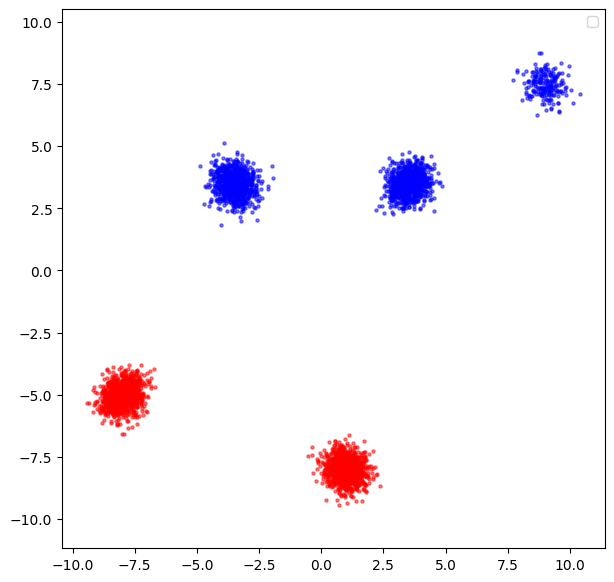

In [ ]:
import matplotlib.pyplot as plt

# ---------------------------------------
# gmm_A からサンプル
# ---------------------------------------
_, alpha_A, means_A, covs_A = gmm_A
X = sample_from_gmm(alpha_A, means_A, covs_A, N=2000)

# ---------------------------------------
# gmm_B からサンプル
# ---------------------------------------
_, alpha_B, means_B, covs_B = gmm_B
Y = sample_from_gmm(alpha_B, means_B, covs_B, N=2000)

plt.figure(figsize=(7,7))
plt.scatter(X[:,0], X[:,1], s=5, c='red', alpha=0.5)
plt.scatter(Y[:,0], Y[:,1], s=5, c='blue',  alpha=0.5)
plt.legend()
plt.axis("equal")

plt.show()


[[4.53008000e-01 8.95470800e-04 1.38879439e-11]
 [5.49200015e-03 1.31080983e-01 5.65513139e-07]]
0.590477018835913


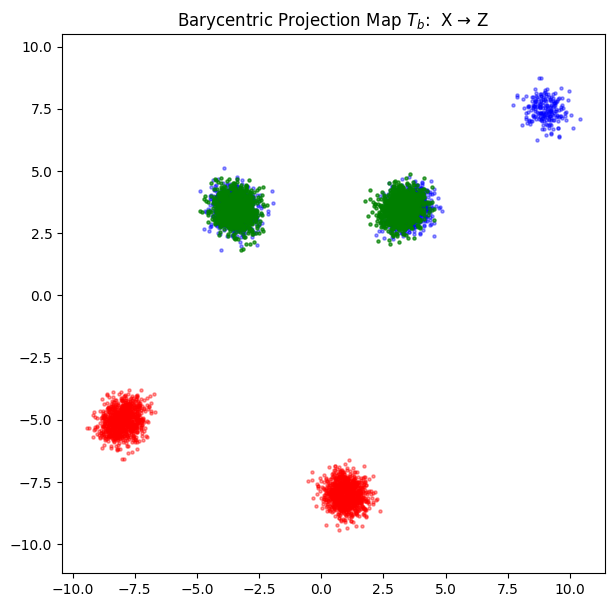

[[ 3.4280625   3.87851319]
 [-3.44875003  3.26659017]
 [-3.4273642   3.7632573 ]
 ...
 [ 3.3998178   3.23670325]
 [ 3.26236774  4.16713709]
 [ 2.86455282  3.1088678 ]]


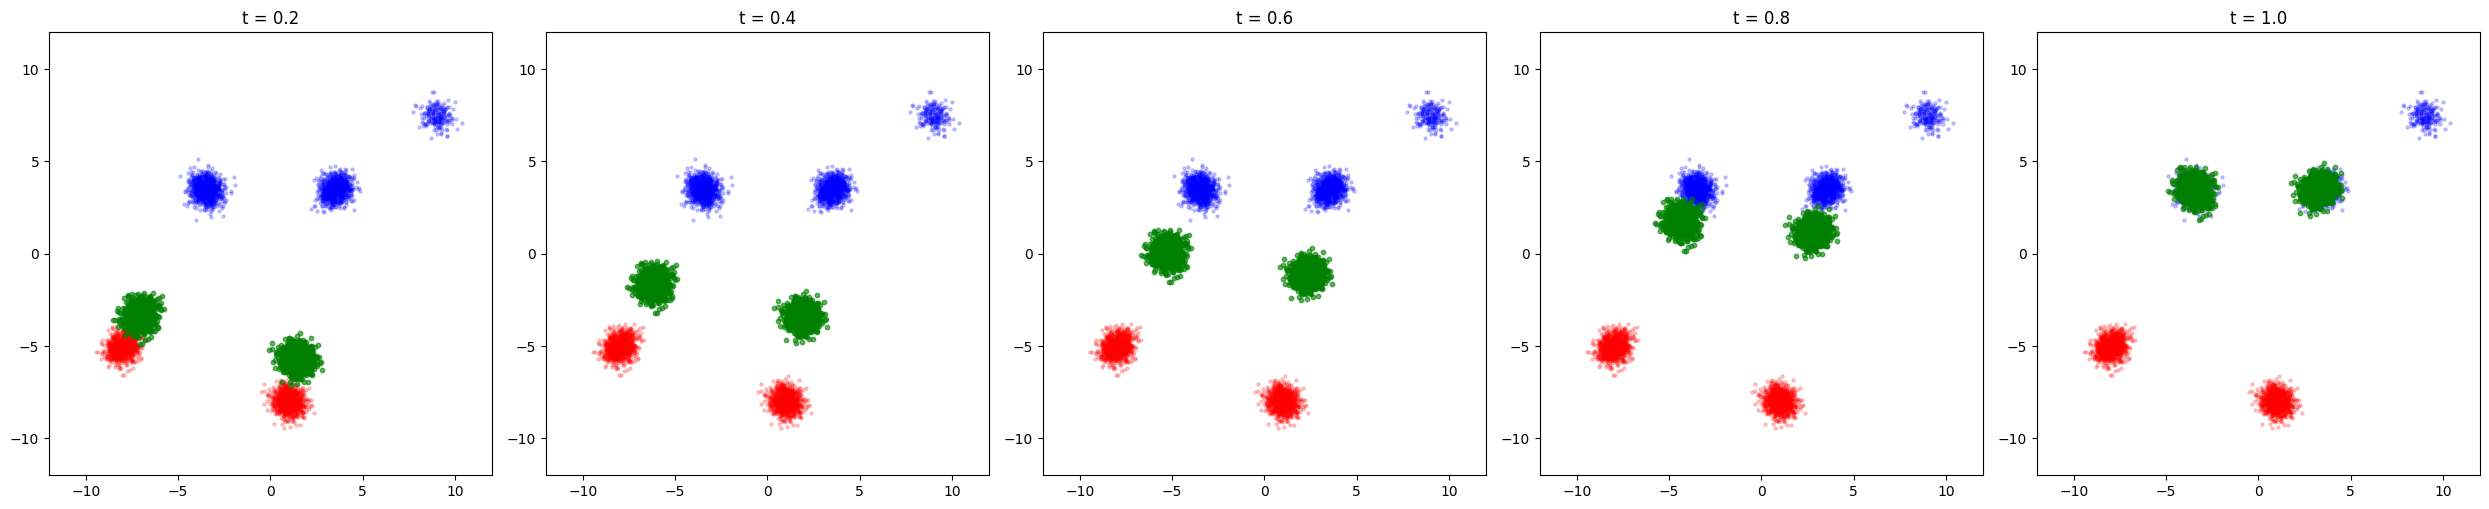

In [ ]:
Lambda = 0.25
epsilon = 0.03
# --- Z を計算 ---
Z = compute_T_X_to_Z_C(
        X, Y,
        n_components_X=2,
        n_components_Y=3, # 元の GMM 推定に合わせて適宜変える
        epsilon=epsilon,
        Lambda=Lambda,
        nb_dummies=1
)


# --- 可視化 ---
plt.figure(figsize=(7,7))

xmin, xmax = [-12, 12]
ymin, ymax = [-12, 12]

# 元の X（青）
plt.scatter(X[:,0], X[:,1], s=5, c='red', alpha=0.4)

# 元の Y（赤）
plt.scatter(Y[:,0], Y[:,1], s=5, c='blue', alpha=0.4)

# 移送後 Z（緑）
plt.scatter(Z[:,0], Z[:,1], s=5, c='green', alpha=0.7)

plt.axis("equal")
plt.title("Barycentric Projection Map $T_b$:  X → Z")
ax_main = plt.gca()

plt.show()
print(Z)





import matplotlib.pyplot as plt
import numpy as np

# パラメータ設定
ts = np.arange(0.2, 1.01, 0.2)
n_plots = len(ts)

# 横一列に並べるための設定
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))

for i, t in enumerate(ts):
    # 線形補間
    Pt = (1 - t) * X + t * Z

    ax = axes[i]

    # 背景として X と Y を描画
    ax.scatter(X[:, 0], X[:, 1], s=5, c='red', alpha=0.2, label="X")
    ax.scatter(Y[:, 0], Y[:, 1], s=5, c='blue', alpha=0.2, label="Y")

    # 現在の補間点 Pt を描画
    ax.scatter(Pt[:, 0], Pt[:, 1], s=10, c='green', alpha=0.6, label=f"P_t")

    ax.set_title(f"t = {t:.1f}")
    ax.set_aspect("equal")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)


plt.tight_layout()

plt.savefig(f"point_reg_{epsilon}_lambda_{Lambda}.eps", format='eps', bbox_inches='tight')
plt.show()

[[4.58090298e-01 3.73762577e-02 3.34444559e-05]
 [4.09702291e-04 4.03623742e-01 1.00466555e-01]]
0.9999999998224651


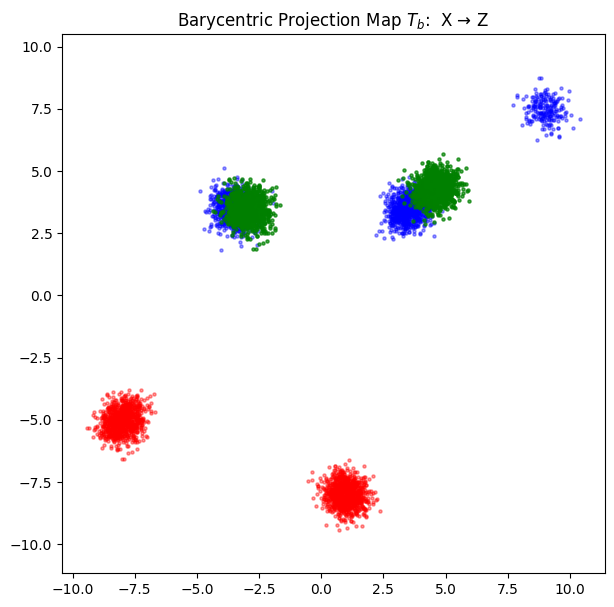

[[ 4.79055053  4.66500188]
 [-2.93614652  3.26910159]
 [-2.90943233  3.76442755]
 ...
 [ 4.77833595  4.02346916]
 [ 4.61688031  4.95775081]
 [ 4.24398771  3.90830578]]


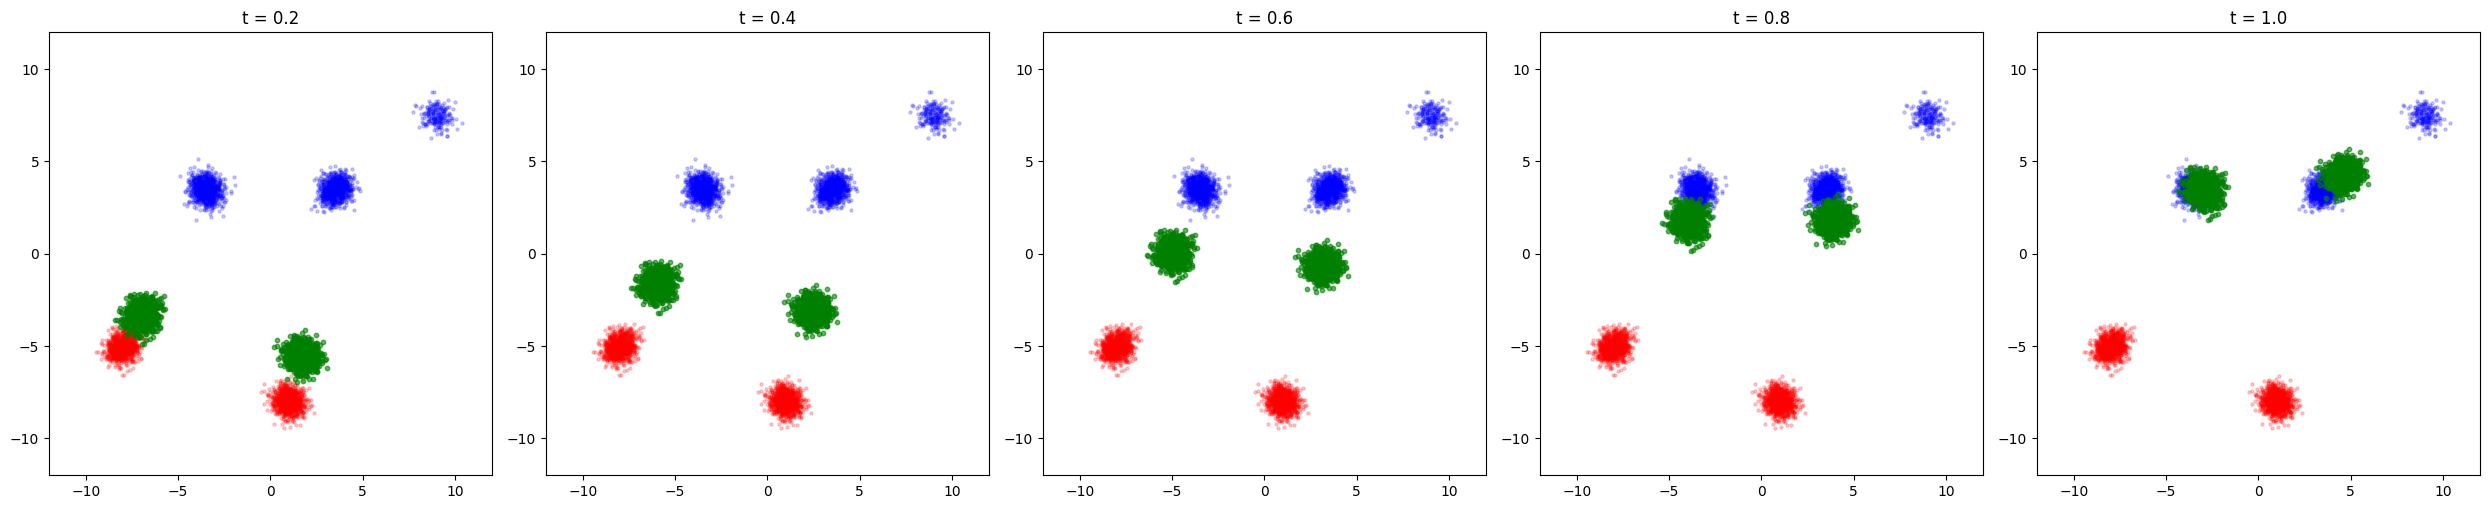

In [ ]:
Lambda = 0.5
epsilon = 0.03
# --- Z を計算 ---
Z = compute_T_X_to_Z_C(
        X, Y,
        n_components_X=2,
        n_components_Y=3, # 元の GMM 推定に合わせて適宜変える
        epsilon=epsilon,
        Lambda=2*Lambda,
        nb_dummies=1
)


# --- 可視化 ---
plt.figure(figsize=(7,7))

# 元の X（青）
plt.scatter(X[:,0], X[:,1], s=5, c='red', alpha=0.4)

# 元の Y（赤）
plt.scatter(Y[:,0], Y[:,1], s=5, c='blue', alpha=0.4)

# 移送後 Z（緑）
plt.scatter(Z[:,0], Z[:,1], s=5, c='green', alpha=0.7)

plt.axis("equal")
plt.title("Barycentric Projection Map $T_b$:  X → Z")
ax_main = plt.gca()
xmin, xmax = [-12, 12]
ymin, ymax = [-12, 12]
plt.show()
print(Z)





import matplotlib.pyplot as plt
import numpy as np

# パラメータ設定
ts = np.arange(0.2, 1.01, 0.2)
n_plots = len(ts)

# 横一列に並べるための設定
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))

for i, t in enumerate(ts):
    # 線形補間
    Pt = (1 - t) * X + t * Z

    ax = axes[i]

    # 背景として X と Y を描画
    ax.scatter(X[:, 0], X[:, 1], s=5, c='red', alpha=0.2, label="X")
    ax.scatter(Y[:, 0], Y[:, 1], s=5, c='blue', alpha=0.2, label="Y")

    # 現在の補間点 Pt を描画
    ax.scatter(Pt[:, 0], Pt[:, 1], s=10, c='green', alpha=0.6, label=f"P_t")

    ax.set_title(f"t = {t:.1f}")
    ax.set_aspect("equal")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)


plt.tight_layout()

plt.savefig(f"point_reg_{epsilon}_lambda_{Lambda}.eps", format='eps', bbox_inches='tight')
plt.show()